<a href="https://colab.research.google.com/github/barindersingh-coder/AICTE/blob/main/fakejob.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
#from google.colab import files
#uploaded = files.upload()

(17880, 18)
Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seco

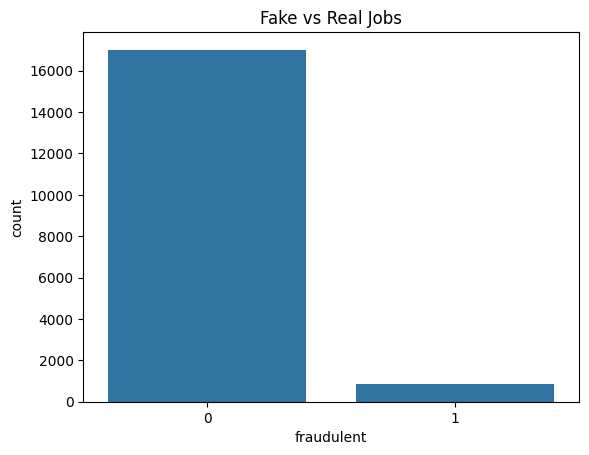

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("fake_job_postings.csv")

# Basic info
print(df.shape)
print(df.columns)
print(df.head())

# -------------------------
# CHECK MISSING VALUES
# -------------------------
print("\nMissing Values:\n")
print(df.isnull().sum())

# -------------------------
# TARGET DISTRIBUTION
# -------------------------
print("\nFake vs Real:\n")
print(df['fraudulent'].value_counts())

sns.countplot(x='fraudulent', data=df)
plt.title("Fake vs Real Jobs")
plt.show()

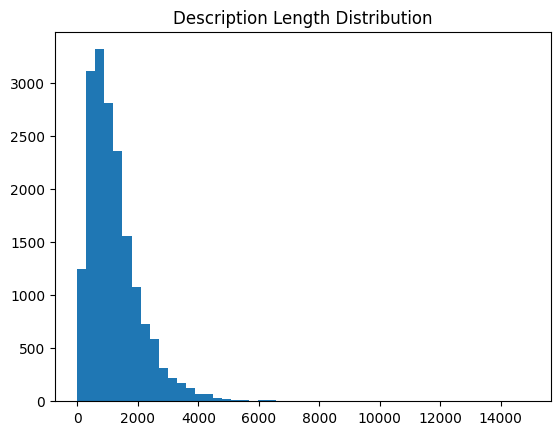

In [ ]:
# Length of descriptions
df['desc_length'] = df['description'].fillna("").apply(len)

plt.hist(df['desc_length'], bins=50)
plt.title("Description Length Distribution")
plt.show()

In [ ]:
# Check useful columns
useful_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']

for col in useful_cols:
    print(f"\nColumn: {col}")
    print(df[col].head(2))


Column: title
0                             Marketing Intern
1    Customer Service - Cloud Video Production
Name: title, dtype: object

Column: company_profile
0    We're Food52, and we've created a groundbreaki...
1    90 Seconds, the worlds Cloud Video Production ...
Name: company_profile, dtype: object

Column: description
0    Food52, a fast-growing, James Beard Award-winn...
1    Organised - Focused - Vibrant - Awesome!Do you...
Name: description, dtype: object

Column: requirements
0    Experience with content management systems a m...
1    What we expect from you:Your key responsibilit...
Name: requirements, dtype: object

Column: benefits
0                                                  NaN
1    What you will get from usThrough being part of...
Name: benefits, dtype: object


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Combine important columns
df['text'] = (
    df['title'].fillna('') + " " +
    df['company_profile'].fillna('') + " " +
    df['description'].fillna('') + " " +
    df['requirements'].fillna('') + " " +
    df['benefits'].fillna('')
)

# Cleaning function
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df['clean_text'] = df['text'].apply(preprocess)

print(df[['clean_text', 'fraudulent']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                          clean_text  fraudulent
0  marketing intern food created groundbreaking a...           0
1  customer service cloud video production second...           0
2  commissioning machinery assistant cma valor se...           0
3  account executive washington dc passion improv...           0
4  bill review manager spotsource solutions llc g...           0


In [ ]:
df = df[df['clean_text'].str.len() > 50]

In [ ]:
print(df['fraudulent'].value_counts(normalize=True))

fraudulent
0    0.951939
1    0.048061
Name: proportion, dtype: float64


In [ ]:
X = df['clean_text']
y = df['fraudulent']

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Model 1: Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

# Model 2: Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_vec, y_train)

# Predictions
nb_pred = nb.predict(X_test_vec)
lr_pred = lr.predict(X_test_vec)

print("Naive Bayes:\n", classification_report(y_test, nb_pred))
print("\nLogistic Regression:\n", classification_report(y_test, lr_pred))

Naive Bayes:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      3393
           1       0.91      0.43      0.59       182

    accuracy                           0.97      3575
   macro avg       0.94      0.72      0.79      3575
weighted avg       0.97      0.97      0.96      3575


Logistic Regression:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      3393
           1       0.66      0.89      0.76       182

    accuracy                           0.97      3575
   macro avg       0.82      0.93      0.87      3575
weighted avg       0.98      0.97      0.97      3575



In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [ ]:
def predict_job(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])
    result = model.predict(vec)

    return "FAKE" if result[0] == 1 else "REAL"

In [ ]:
def predict_job(text):
    # Step 1: preprocess
    text = preprocess(text)

    # Step 2: convert to vector
    vec = vectorizer.transform([text])

    # Step 3: get probability
    probs = model.predict_proba(vec)[0][1]

    # Step 4: threshold logic
    if probs > 0.6:
        return "FAKE"
    else:
        return "REAL"

In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
print(predict_job("Earn money fast with no experience, pay registration fee"))

FAKE


In [ ]:
print(predict_job("Earn money fast, no experience, pay fee"))   # should be FAKE
print(predict_job("Hiring software engineer with 2 years experience"))  # should be REAL

FAKE
REAL


In [ ]:
import requests
from bs4 import BeautifulSoup

def extract_text(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    res = requests.get(url, headers=headers)

    if res.status_code != 200:
        return None

    soup = BeautifulSoup(res.text, "html.parser")
    text = soup.get_text()

    return text

In [ ]:
def predict_from_url(url):
    text = extract_text(url)

    if not text or len(text) < 100:
        return "Could not extract content. Please paste manually."

    return predict_job(text)

In [ ]:
text = extract_text("https://resources.workable.com/billing-manager-job-description")
print(text[:1000])

















Billing Manager Job Description [+2024 TEMPLATE]


































































Skip to content

















                        Topics                    






              topics            

              I need help with...            


Mobilizing AI in my work


Evaluating candidates


Working together with others


Maintaining hiring pipelines


Developing & retaining people


Ensuring compliance


Finding and attracting people


Establishing an employer brand


Digitizing work processes


Candidate/employee experiences






                Or browse by trending topics:              



Flex work

 A flexible workplace means new ways of working. Pick up tips and tricks for success. 



employee experience

 Job quits are rising and engagement is dropping. How do you reverse that? 



AI @ work

 Artificial intelligence is changing our day-to-day working processes. Learn to stay ahead. 











                     

In [ ]:
import requests
from bs4 import BeautifulSoup

def extract_text(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    res = requests.get(url, headers=headers)

    soup = BeautifulSoup(res.text, "html.parser")

    # Remove unwanted tags
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()

    # Extract only paragraphs
    texts = []
    for p in soup.find_all("p"):
        text = p.get_text(strip=True)
        if len(text) > 50:
            texts.append(text)

    return " ".join(texts)

In [ ]:
text = extract_text("https://resources.workable.com/billing-manager-job-description")
print(text[:1000])

A Billing Manager is a professional who is responsible for managing all activities and staff in the billing function. They oversee the development of policies and procedures that ensure timely, accurate customer invoicing. Workable's content team brings its HR & employment expertise to Resources. Use this Billing Manager job description to advertise your vacancies and find qualified candidates. Feel free to modify responsibilities and requirements based on your needs. We are looking for aBilling Managerto join our team and ensure that customers are billed the correct amount for each job that we deliver. Billing Manager responsibilities include working with customers to reconcile billing issues, working with the accounting department to ensure all accounts are up to date, and helping with the training of new employees in the billing department. Ultimately, you will work directly with customers to ensure all bills are accurate, along with other departments in our company as needed.


In [ ]:
print(predict_job("""A Billing Manager is a professional who is responsible for managing all activities and staff in the billing function...
"""))

FAKE


In [ ]:
def predict_job_debug(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])

    prob = model.predict_proba(vec)[0][1]

    print("Fake Probability:", prob)

    return "FAKE" if prob > 0.5 else "REAL"

In [ ]:
predict_job_debug("""A Billing Manager is a professional who is responsible for managing all activities and staff in the billing function. They oversee the development of policies and procedures that ensure timely, accurate customer invoicing...""")

Fake Probability: 0.5895031902099843


'FAKE'

In [ ]:
def predict_job(text):
    text = preprocess(text)
    vec = vectorizer.transform([text])

    prob = model.predict_proba(vec)[0][1]

    if prob > 0.7:
        return f"FAKE ({prob:.2f})"
    elif prob > 0.5:
        return f"SUSPICIOUS ({prob:.2f})"
    else:
        return f"REAL ({1-prob:.2f})"

In [ ]:
text = extract_text("https://resources.workable.com/billing-manager-job-description")

In [ ]:
text = """A Billing Manager is a professional who is responsible for managing all activities and staff in the billing function. They oversee the development of policies and procedures that ensure timely, accurate customer invoicing. Workable's content team brings its HR & employment expertise to Resources. Use this Billing Manager job description to advertise your vacancies and find qualified candidates. Feel free to modify responsibilities and requirements based on your needs. We are looking for a Billing Manager to join our team and ensure that customers are billed the correct amount for each job that we deliver. Billing Manager responsibilities include working with customers to reconcile billing issues, working with the accounting department to ensure all accounts are up to date, and helping with the training of new employees in the billing department. Ultimately, you will work directly with customers to ensure all bills are accurate, along with other departments in our company as needed."""
print(predict_job(text))

REAL (0.59)


In [ ]:
print(predict_job("Earn money fast, no experience, pay fee"))   # should be FAKE
print(predict_job("Hiring software engineer with experience"))  # should be REAL

FAKE (0.90)
REAL (0.72)


In [ ]:
df['text'] = (
    "TITLE: " + df['title'].fillna('') + " " +
    "COMPANY: " + df['company_profile'].fillna('') + " " +
    "DESCRIPTION: " + df['description'].fillna('') + " " +
    "REQUIREMENTS: " + df['requirements'].fillna('') + " " +
    "BENEFITS: " + df['benefits'].fillna('')
)

In [ ]:
df['clean_text'] = df['text'].apply(preprocess)

In [ ]:
def extract_text(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    res = requests.get(url, headers=headers)
    soup = BeautifulSoup(res.text, "html.parser")

    title = soup.title.get_text() if soup.title else ""

    paragraphs = " ".join([p.get_text() for p in soup.find_all("p")])

    return f"TITLE: {title} DESCRIPTION: {paragraphs}"

In [ ]:
TfidfVectorizer(max_features=5000, ngram_range=(1,2))

TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [ ]:
print(predict_job("TITLE: Software Engineer DESCRIPTION: We are hiring a software engineer with 2 years experience in Python and problem solving"))

REAL (0.80)


In [ ]:
print(predict_job("TITLE: Work from home job DESCRIPTION: Earn 5000 weekly with no experience, pay registration fee now"))

FAKE (0.82)


In [ ]:
url = "https://resources.workable.com/software-engineer-job-description"

text = extract_text(url)
print(text[:500])   # check extracted text
print(predict_job(text))

TITLE: Software Engineer Job Description [+2024 TEMPLATE] DESCRIPTION: 
              topics              A flexible workplace means new ways of working. Pick up tips and tricks for success.   Job quits are rising and engagement is dropping. How do you reverse that?   Artificial intelligence is changing our day-to-day working processes. Learn to stay ahead.  
              templates & guides              Get insights, guidance, and tips from those in the know.   Real-life stories direct from the
REAL (0.89)


In [ ]:
def extract_text(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    res = requests.get(url, headers=headers)
    soup = BeautifulSoup(res.text, "html.parser")

    title = soup.title.get_text() if soup.title else ""

    paragraphs = " ".join([p.get_text() for p in soup.find_all("p")])

    return f"TITLE: {title} DESCRIPTION: {paragraphs}"

In [ ]:
url = "https://resources.workable.com/software-engineer-job-description"

text = extract_text(url)

print(text[:500])   # check feature tags
print(predict_job(text))

TITLE: Software Engineer Job Description [+2024 TEMPLATE] DESCRIPTION: 
              topics              A flexible workplace means new ways of working. Pick up tips and tricks for success.   Job quits are rising and engagement is dropping. How do you reverse that?   Artificial intelligence is changing our day-to-day working processes. Learn to stay ahead.  
              templates & guides              Get insights, guidance, and tips from those in the know.   Real-life stories direct from the
REAL (0.89)


In [ ]:
def extract_text(url):
    headers = {"User-Agent": "Mozilla/5.0"}
    res = requests.get(url, headers=headers)
    soup = BeautifulSoup(res.text, "html.parser")

    # remove unwanted sections
    for tag in soup(["nav", "footer", "script", "style"]):
        tag.decompose()

    title = soup.title.get_text() if soup.title else ""

    paragraphs = []
    for p in soup.find_all("p"):
        text = p.get_text(strip=True)
        if len(text) > 50:
            paragraphs.append(text)

    return f"TITLE: {title} DESCRIPTION: {' '.join(paragraphs)}"

In [ ]:
print(predict_job("TITLE: Online Job DESCRIPTION: Earn 5000 weekly, no experience, pay fee"))

SUSPICIOUS (0.64)


In [ ]:
url = "https://www.betterteam.com/software-developer-job-description"

text = extract_text(url)

print(text[:500])   # check extraction
print(predict_job(text))

TITLE: Software Developer Job Description DESCRIPTION: The job of a software developer depends on the needs of the company, organization, or team they are on. Some build and maintain systems that run devices and networks. Others develop applications that make it possible for people to perform specific tasks on computers, cellphones, or other devices. If you're looking for someone who can do both back-end and front-end software development, you'll want a full-stack developer. Our company is seeki
REAL (0.95)


In [ ]:
url = "https://www.indeed.com/hire/job-description/software-engineer"

text = extract_text(url)

print(text[:500])   # check extraction
print(predict_job(text))

TITLE: Software Engineer Job Description [Updated for 2026] DESCRIPTION: Indeed’s Employer Guide helps businesses grow and manage their workforce. With over 15,000 articles in 6 languages, we offer tactical advice, how-tos and best practices to help businesses hire and retain great employees. A21833116074software engineer40.21software developer11.75software5.13java developer5.09computer science3.0765962079643333000.00131359.34296000.00YEARLY43382163572026-03-012026-03-312026-02-012026-02-282026-
REAL (0.94)


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'model.pkl', 'vectorizer.pkl', 'fake_job_postings.csv', 'sample_data']


In [ ]:
url = "https://acceptance.amdoxlearning.in/"
text = extract_text(url)

print("----- Extracted Text -----")
print(text[:500])

print("\n----- Prediction -----")
print(predict_job(text))

----- Extracted Text -----
TITLE: Amdox Internship Offer Acceptance Form DESCRIPTION: Enter the Correct Email which is registered in the internship, other details will be auto filled. To prepare for the job program it's necessary to access all the resources.

----- Prediction -----
REAL (0.78)


In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(text[:500])

TITLE: Gokhair Travel Innovations Pvt Ltd hiring Finance Manager in Kochi, Kerala, India | LinkedIn DESCRIPTION: See who Gokhair Travel Innovations Pvt Ltd has hired for this role Direct message the job poster from Gokhair Travel Innovations Pvt Ltd We are looking for a Finance Manager withstrong experience in the travel & tourism industry, especially in handling international payments, group tours, and bulk tour operations. • Oversee daily accounting operations across offices • Manage internati


In [ ]:
files.download("fake_job_postings.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil

shutil.make_archive("project_files", 'zip', "/content")

RuntimeError: File size too large, try using force_zip64

In [ ]:
def is_valid_job(text):
    keywords = ["responsibilities", "requirements", "job", "experience", "role"]
    return any(word in text.lower() for word in keywords)

In [ ]:
def detect_scam_patterns(text, url):
    suspicious_words = ["pay", "fee", "registration", "acceptance", "form"]

    if any(word in text.lower() for word in suspicious_words):
        return True

    if "acceptance" in url or "form" in url:
        return True

    return False

In [ ]:
def smart_predict(text, url=""):

    # Step 1: Check if valid job
    if not is_valid_job(text):
        return "⚠️ Not a proper job posting"

    # Step 2: Check scam patterns
    if detect_scam_patterns(text, url):
        return "🚨 Suspicious / Possible Scam"

    # Step 3: ML prediction
    return predict_job(text)

In [65]:
def smart_predict(text, url=""):

    # Step 1: Check if valid job
    if not is_valid_job(text):
        return "⚠️ Not a proper job posting"

    # Step 2: Check scam patterns
    if detect_scam_patterns(text, url):
        return "🚨 Suspicious / Possible Scam"

    # Step 3: ML prediction
    return predict_job(text)

In [66]:
text = extract_text("https://acceptance.amdoxlearning.in")

print(smart_predict(text, "https://acceptance.amdoxlearning.in"))

🚨 Suspicious / Possible Scam


In [67]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9706293706293706


In [68]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9706293706293706


In [69]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3393
           1       0.66      0.89      0.76       182

    accuracy                           0.97      3575
   macro avg       0.82      0.93      0.87      3575
weighted avg       0.98      0.97      0.97      3575



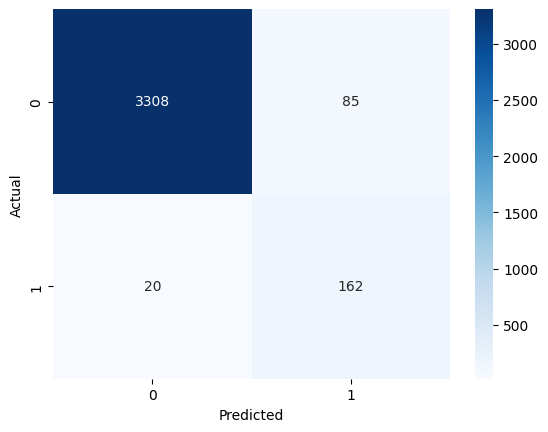

In [70]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
y_probs = model.predict_proba(X_test_vec)[:, 1]

for t in [0.5, 0.6, 0.7, 0.8]:
    y_pred_t = (y_probs > t).astype(int)
    print(f"\nThreshold = {t}")
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred_t))


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3393
           1       0.66      0.89      0.76       182

    accuracy                           0.97      3575
   macro avg       0.82      0.93      0.87      3575
weighted avg       0.98      0.97      0.97      3575


Threshold = 0.6
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3393
           1       0.79      0.86      0.82       182

    accuracy                           0.98      3575
   macro avg       0.89      0.92      0.91      3575
weighted avg       0.98      0.98      0.98      3575


Threshold = 0.7
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3393
           1       0.88      0.80      0.84       182

    accuracy                           0.98      3575
   macro avg       0.94      0.90      0.92      3575
weighted avg       0.98

In [72]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
